In [3]:
import zarr

dataset_path = '../dataset_generation/full_dataset/dataset.zarr'

# Open the dataset in read mode
root = zarr.open_group(dataset_path, mode='r')

dataset_size = 10000

# Access the arrays
X_flux = root["X_flux_coeffs"][:dataset_size]
X_wts  = root["X_weights"][:dataset_size]
Y_flux = root["Y_flux_coeffs"][:dataset_size]
Y_pow  = root["Y_power_coeffs"][:dataset_size]
Y_keff = root["Y_keff"][:dataset_size]
Y_wts  = root["Y_weights"][:dataset_size]

# Convert all data into pytorch tensors of the appropriate shape

import numpy as np
import torch

X_flux = np.moveaxis(X_flux, -1, 2)
Y_flux = np.moveaxis(Y_flux, -1, 2)

X_flux = torch.tensor(X_flux, dtype=torch.float32)
X_wts  = torch.tensor(X_wts, dtype=torch.float32)

Y_flux = torch.tensor(Y_flux, dtype=torch.float32)
Y_pow  = torch.tensor(Y_pow, dtype=torch.float32)
Y_keff = torch.tensor(Y_keff, dtype=torch.float32)
Y_wts  = torch.tensor(Y_wts, dtype=torch.float32)

In [4]:
import torch.nn as nn
import torch.nn.functional as F


# Flatten and concatenate inputs
X_flux_flat = X_flux.view(X_flux.size(0), -1)
X_input = torch.cat([X_flux_flat, X_wts], dim=1)

# Output sizes
out_flux_size = Y_flux.view(Y_flux.size(0), -1).size(1)
out_pow_size = Y_pow.view(Y_pow.size(0), -1).size(1)
out_wts_size = Y_wts.size(1)
out_keff_size = 1

# Define the model
class SimpleFCNN(nn.Module):
    def __init__(self, Y_flux_shape, Y_pow_shape, input_dim, hidden_dim=512):
        super().__init__()
        self.Y_flux_shape = Y_flux_shape[1:]  # drop batch dim
        self.Y_pow_shape = Y_pow_shape[1:]    # drop batch dim

        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)

        # Output heads
        self.out_flux = nn.Linear(hidden_dim, out_flux_size)
        self.out_pow = nn.Linear(hidden_dim, out_pow_size)
        self.out_keff = nn.Linear(hidden_dim, out_keff_size)
        self.out_wts = nn.Linear(hidden_dim, out_wts_size)

    def forward(self, X_flux, X_wts):
        # Flatten inputs internally
        X_flux_flat = X_flux.view(X_flux.size(0), -1)
        X = torch.cat([X_flux_flat, X_wts], dim=1)

        x = F.relu(self.fc1(X))
        x = F.relu(self.fc2(x))

        return {
            'flux': self.out_flux(x).view(-1, *self.Y_flux_shape),
            'pow': self.out_pow(x).view(-1, *self.Y_pow_shape),
            'keff': self.out_keff(x).squeeze(-1),
            'wts': self.out_wts(x)
        }


In [5]:
mse = nn.MSELoss()

def compute_loss(pred, Y_flux, Y_pow, Y_keff, Y_wts):
    return (
        mse(pred['flux'], Y_flux) +
        mse(pred['pow'], Y_pow) +
        mse(pred['keff'], Y_keff) +
        mse(pred['wts'], Y_wts)
    )


In [6]:
from torch.utils.data import TensorDataset, random_split, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === 1. Wrap everything in a TensorDataset ===
dataset = TensorDataset(X_flux, X_wts, Y_flux, Y_pow, Y_keff, Y_wts)

# === 2. Split dataset ===
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_set, test_set = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

# === 3. Create DataLoaders ===
train_loader = DataLoader(train_set, batch_size=len(train_set))  # full-batch for now
test_loader = DataLoader(test_set, batch_size=len(test_set))

# === 4. Get one full batch from train set to define input_dim ===
X_flux_train, X_wts_train, Y_flux_train, Y_pow_train, Y_keff_train, Y_wts_train = next(iter(train_loader))

# === 5. Instantiate model with shape info ===
X_input_dim = X_flux_train.view(X_flux_train.size(0), -1).size(1) + X_wts_train.size(1)
model = SimpleFCNN(Y_flux_train.shape, Y_pow_train.shape, input_dim=X_input_dim).to(device)

num_params = sum(p.numel() for p in model.parameters())
print(f"Total number of parameters: {num_params}")

Total number of parameters: 1477341


In [7]:
from tqdm import tqdm

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
epochs = 100
progress_bar = tqdm(range(epochs), desc="Training", position=0)

train_losses = []
test_losses = []
for epoch in progress_bar:
    model.train()

    for X_flux_batch, X_wts_batch, Y_flux_batch, Y_pow_batch, Y_keff_batch, Y_wts_batch in train_loader:
        X_flux_batch = X_flux_batch.to(device)
        X_wts_batch  = X_wts_batch.to(device)
        Y_flux_batch = Y_flux_batch.to(device)
        Y_pow_batch  = Y_pow_batch.to(device)
        Y_keff_batch = Y_keff_batch.to(device)
        Y_wts_batch  = Y_wts_batch.to(device)
        
        pred = model(X_flux_batch, X_wts_batch)
        loss = compute_loss(pred, Y_flux_batch, Y_pow_batch, Y_keff_batch, Y_wts_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        for X_flux_test, X_wts_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test in test_loader:
            X_flux_test = X_flux_test.to(device)
            X_wts_test  = X_wts_test.to(device)
            Y_flux_test = Y_flux_test.to(device)
            Y_pow_test  = Y_pow_test.to(device)
            Y_keff_test = Y_keff_test.to(device)
            Y_wts_test  = Y_wts_test.to(device)

            pred_test = model(X_flux_test, X_wts_test)
            test_loss = compute_loss(pred_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test)

    train_losses.append(loss.item())
    test_losses.append(test_loss.item())
    progress_bar.set_description(f"Epoch {epoch}/{epochs}: Train Loss = {loss.item():.4f} | Test Loss = {test_loss.item():.4f}")

# === 8. Evaluate on test set ===
model.eval()
with torch.no_grad():
    for X_flux_test, X_wts_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test in test_loader:
        X_flux_test = X_flux_test.to(device)
        X_wts_test  = X_wts_test.to(device)
        Y_flux_test = Y_flux_test.to(device)
        Y_pow_test  = Y_pow_test.to(device)
        Y_keff_test = Y_keff_test.to(device)
        Y_wts_test  = Y_wts_test.to(device)

        pred_test = model(X_flux_test, X_wts_test)
        test_loss = compute_loss(pred_test, Y_flux_test, Y_pow_test, Y_keff_test, Y_wts_test)

print(f"Final Test Loss: {test_loss.item():.4f}")


Epoch 99/100: Train Loss = 0.0719 | Test Loss = 0.0710: 100%|██████████| 100/100 [00:28<00:00,  3.56it/s]

Final Test Loss: 0.0710


In [8]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, test_losses, label='Test Loss', marker='s')
plt.yscale('log')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss per Epoch')
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=300)
plt.close()

In [16]:
test_index=-20
model.to("cpu")
with torch.no_grad():
    out = model(X_flux[test_index:test_index+1].cpu(), X_wts[test_index:test_index+1].cpu())

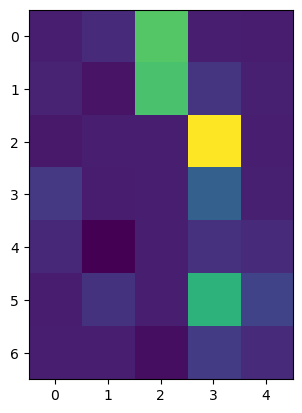

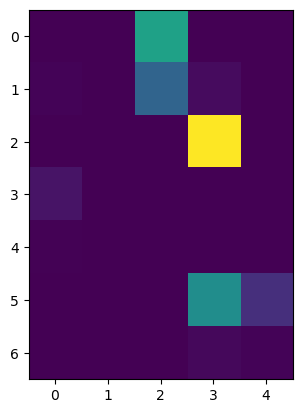

In [17]:
import matplotlib.pyplot as plt

plt.imshow(out['flux'][0, 0, 0, :, :, 0])
plt.show()
plt.imshow(Y_flux[test_index, 0, 0, :, :, 0])
plt.show()

In [18]:
out['keff'], Y_keff[test_index]

(tensor([0.7489]), tensor(0.7324))

In [20]:
out['wts'], Y_wts[test_index]

(tensor([[0.3360, 0.3173, 0.2180, 0.2354]]),
 tensor([0.2955, 0.2928, 0.2002, 0.2115]))

## Compare the Full Flux Surface Expansion

In [29]:
from pincell_moment_utils import postprocessing as pp
from pincell_moment_utils.datagen import DefaultPincellParameters

energy_filters = DefaultPincellParameters().get_energy_filters()

pred_coefficients = np.moveaxis(out['flux'][0].cpu().numpy(), 1, -1)
true_coefficients = np.moveaxis(Y_flux[test_index].cpu().numpy(), 1, -1)

pred_expansion = pp.surface_expansion(np.clip(pred_coefficients, a_min=0, a_max=None), energy_filters, expansion_type='bernstein_bernstein')
expansion = pp.surface_expansion(true_coefficients, energy_filters, expansion_type='bernstein_bernstein')

In [31]:
np.clip(pred_coefficients, a_min=0, a_max=None)

array([[[[[1.30310506e-02],
          [4.99134213e-02],
          [0.00000000e+00],
          ...,
          [1.80214942e-02],
          [0.00000000e+00],
          [2.07574908e-02]],

         [[1.85017079e-01],
          [1.44424047e-02],
          [1.97315570e-02],
          ...,
          [0.00000000e+00],
          [0.00000000e+00],
          [1.94781702e-02]],

         [[3.35901356e+00],
          [2.85170460e+00],
          [1.48537958e+00],
          ...,
          [0.00000000e+00],
          [0.00000000e+00],
          [0.00000000e+00]],

         [[1.03635909e-02],
          [0.00000000e+00],
          [2.99637280e-02],
          ...,
          [8.66614562e-03],
          [0.00000000e+00],
          [0.00000000e+00]],

         [[0.00000000e+00],
          [2.72389427e-02],
          [0.00000000e+00],
          ...,
          [5.53430617e-02],
          [1.82454363e-02],
          [2.27721594e-02]]],


        [[[9.27433893e-02],
          [0.00000000e+00],
          [1.8538

In [13]:
true_coefficients[0, :, :, 0]

array([[[0.        ],
        [0.        ],
        [3.7583897 ],
        [0.        ],
        [0.        ]],

       [[0.06658287],
        [0.        ],
        [2.1185129 ],
        [0.19180672],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [6.58094   ],
        [0.        ]],

       [[0.34700775],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.04886367],
        [0.        ],
        [0.        ],
        [0.        ],
        [0.        ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [3.2240427 ],
        [0.885784  ]],

       [[0.        ],
        [0.        ],
        [0.        ],
        [0.12899669],
        [0.05264866]]], dtype=float32)

In [32]:
pred_expansion.integrate_flux(0), expansion.integrate_flux(0)

(360256.2927619294, 0.999999937323981)

/home/mlouis9/shared/Educational Stuffs/Classes/Spring 2025/Stat ML/Project/data_generation/src/pincell_moment_utils/plotting.py:48: RuntimeWarning: invalid value encountered in divide
  expansion_vals = np.abs(expansion_vals) / np.abs(compare_expansion.evaluate_on_grid(surface, (space_vals, angle_vals, energy_vals)))


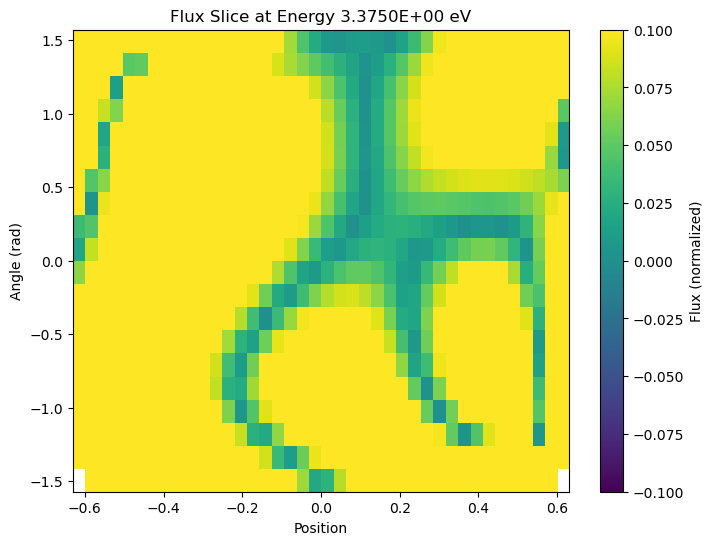

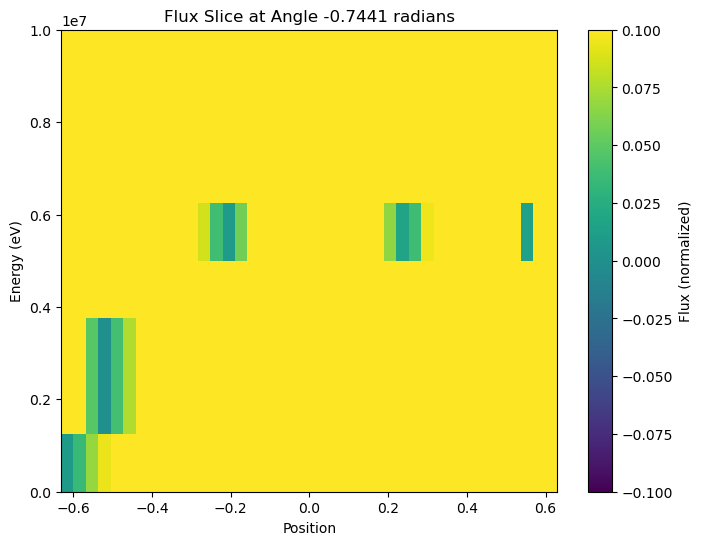

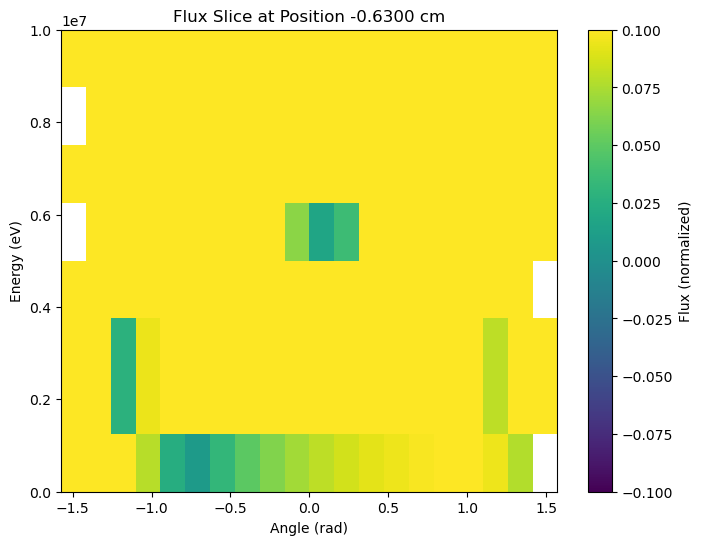

In [33]:
from pincell_moment_utils.plotting import plot_expansion

plot_expansion(expansion, 0, 5, 4, 0, 40, 20, incident=False, compare_expansion=pred_expansion)

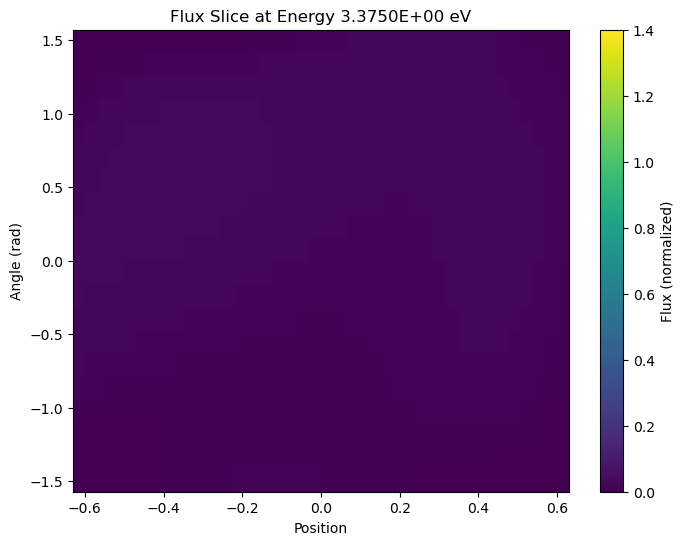

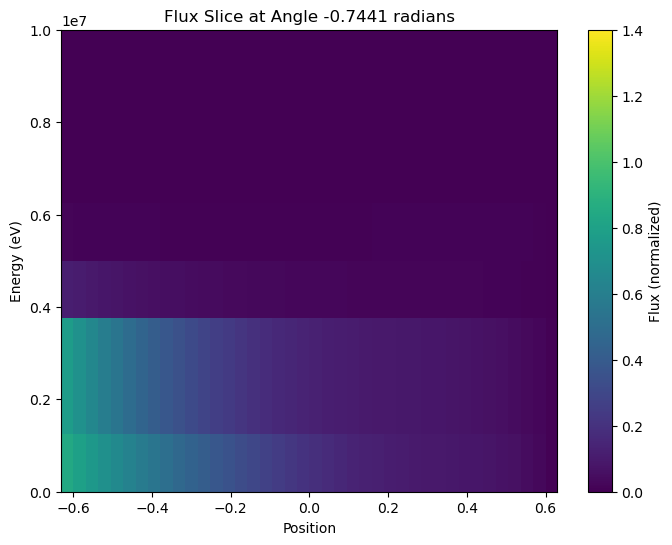

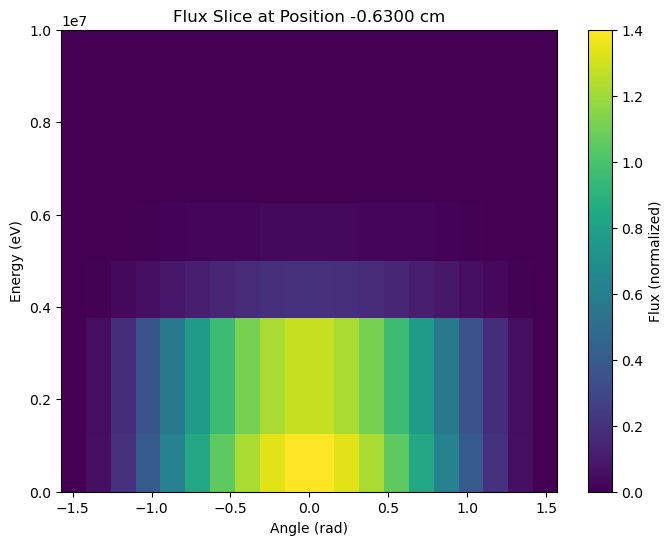

In [34]:
plot_expansion(expansion, 0, 5, 4, 0, 40, 20, incident=False)

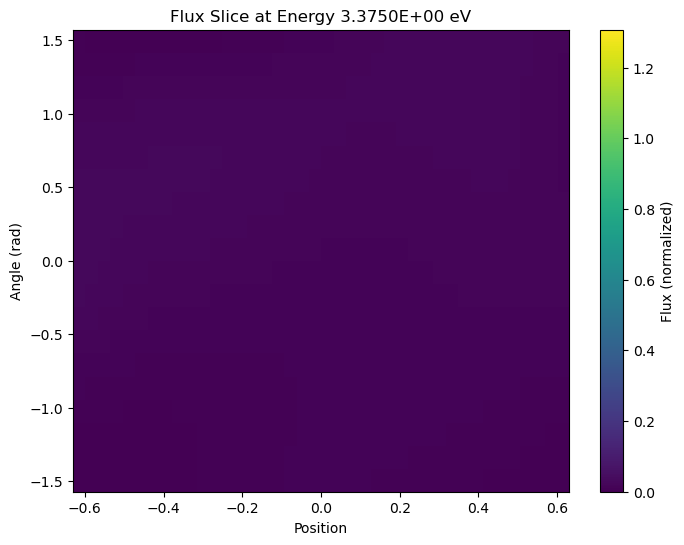

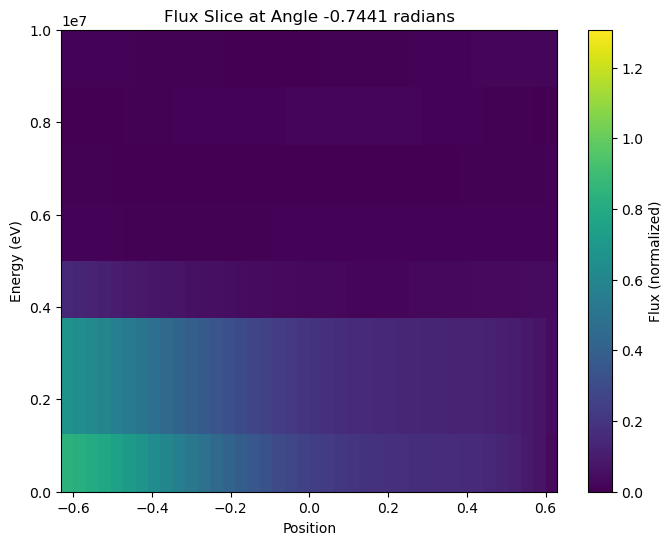

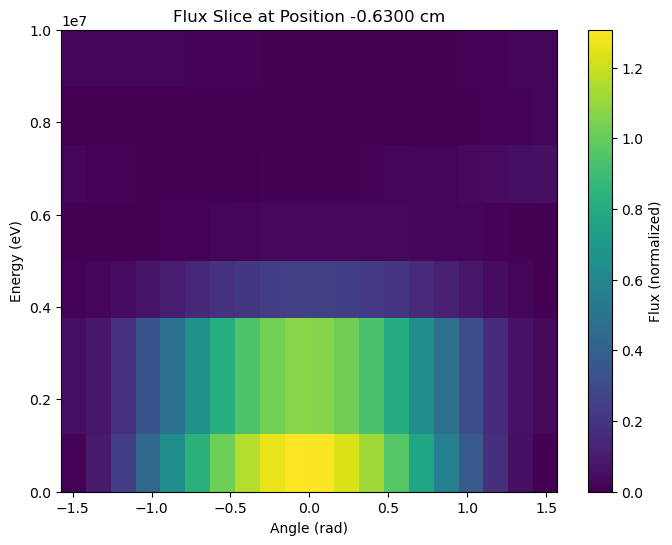

In [36]:
plot_expansion(pred_expansion, 0, 5, 4, 0, 40, 20, incident=False)